# QF 627 Programming and Computational Finance
## Problem Set `5` | `Questions`

> Hi Team! 👋

> The current problem set has two main parts. Questions 1 through 7 are scenario-based, giving you a taste of day-to-day operations as a buy-side Quant in the field. Questions 8 through 12 will help you explore a technical indicator for detecting momentum signals—namely, the Moving Average Convergence Divergence (MACD).

> As always, these questions have been carefully designed to guide your optimal learning. While you read and answer the questions, you’ll be able to feel my affection for you all 🙌

> Enjoy 🤗

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 through 7 are based on the following scenario. After reading it, please respond to the associated sub-questions.

> Suppose that you've been appointed as a Quantitative Researcher in the process-driven investing division of a leading hedge fund. As part of your onboarding challenge, you are handed data (`alphas.csv`) for three experimental trading models, codenamed Alphas A, B, and C. These models, each initiated with a capital of 100K, demonstrate nearly identical Sharpe ratios across a span of 1120 trading days. Intrigued by this uniformity yet aware of the Sharpe ratio's shortcomings, you embark on a journey to dissect the Alphas' performance through a multifaceted quantitative lens.

In [3]:
df =\
pd.read_csv("alphas.csv",
            index_col=0,
            parse_dates=True)

<Axes: >

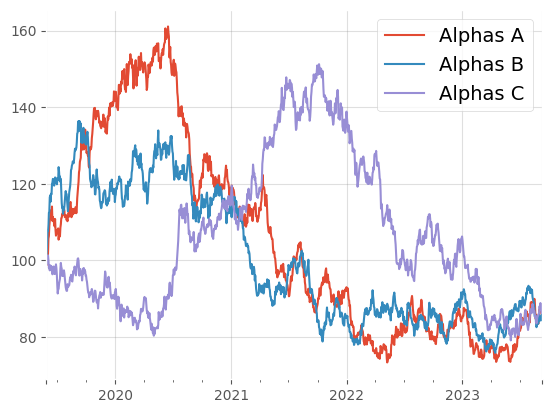

In [4]:
df.plot()

### <font color = blue> 👉 Question 1</font>. Sharpe Ratio Diagnostics:

- Given the daily return series for Alphas A, B, and C:

- Derive the annualized Sharpe ratio for each Alpha, with the industry-standard assumption of 252 trading days per annum. In light of these findings, how might you reconsider the perceived risk-adjusted returns of these models?

### <font color = red> Answer 1 is presented in the cell below: </font>

In [5]:
df.columns

Index(['Alphas A', 'Alphas B', 'Alphas C'], dtype='object')

In [6]:
metrics = pd.DataFrame(columns=df.columns)

In [7]:
alphas = df.columns.tolist()

for alpha in alphas:
    df[f"{alpha}_ret"] = np.log(df[alpha] / df[alpha].shift(1))
    sharpe = df[f"{alpha}_ret"].mean() / df[f"{alpha}_ret"].std() * np.sqrt(252)
    print(f"{alpha}: Sharpe Ratio = {sharpe:5f}")
    metrics.loc["Sharpe", alpha] = sharpe

Alphas A: Sharpe Ratio = -0.155830
Alphas B: Sharpe Ratio = -0.165371
Alphas C: Sharpe Ratio = -0.160252


- find max drawdown
- count up days vs down days
- winning day average vs down day average

### <font color = blue> 👉 Question 2</font>. Trajectory of Cumulative Returns:
    
- Visualize and compare the cumulative returns of each Alpha, using both lets-plot and matplotlib libraries.

### <font color = red> Answer 2 is presented in the cell below: </font>

<Axes: >

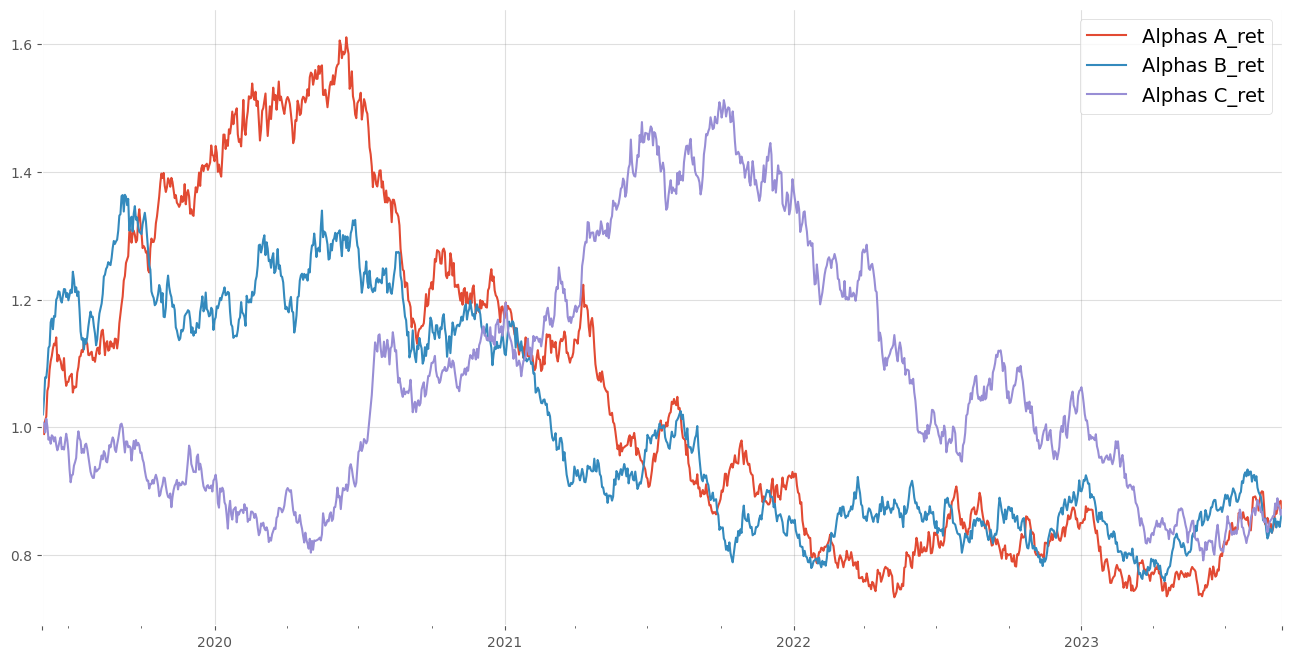

In [8]:
df[df.columns[-3:]].cumsum().apply(np.exp).plot(figsize=[16,8])

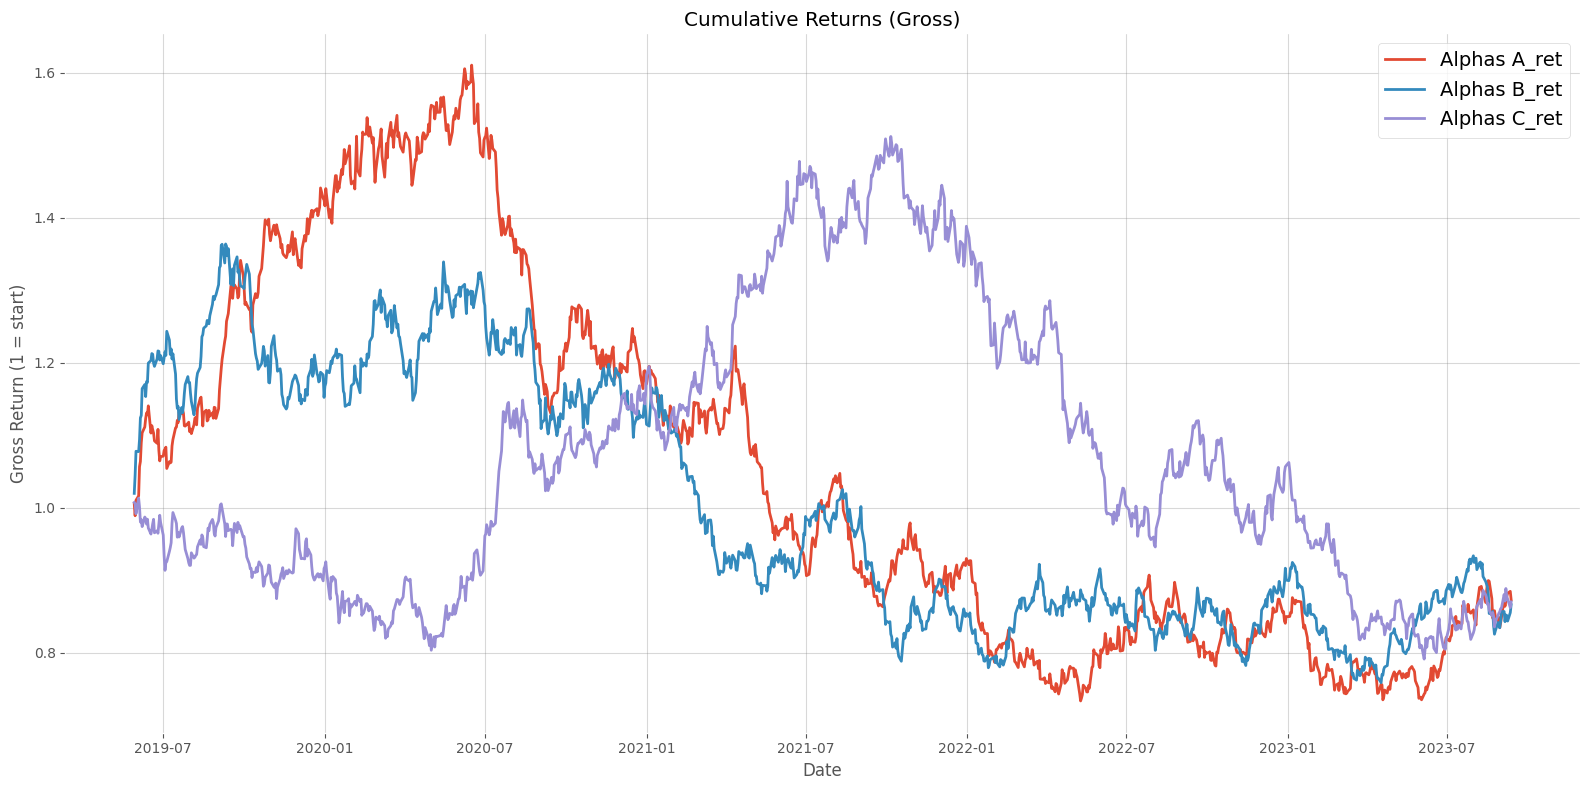

In [9]:
cumrets = df[df.columns[-3:]].cumsum().apply(np.exp)

plt.figure(figsize=[16,8])
for col in cumrets.columns:
    plt.plot(cumrets.index, 
             cumrets[col],
             lw = 2,
             label = col)
plt.title("Cumulative Returns (Gross)")
plt.xlabel("Date")
plt.ylabel("Gross Return (1 = start)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
from lets_plot import *
LetsPlot.setup_html()

cum_melt =\
(
    cumrets
    .copy()
    .reset_index()
    .melt(
        id_vars='index',
        var_name='Alpha',
        value_name='Gross')
)
cum_melt = cum_melt.rename(columns={'index': 'Date'})

# plot
p = (
    ggplot(cum_melt.reset_index(), aes(x='Date', y='Gross', color='Alpha'))
    + geom_line(size=0.5)
    + labs(title='Cumulative Returns', x='Date', y='Gross Return (1 = start)')
    + theme(legend_position='right')
    + ggsize(1200, 500)  
)
p

### <font color = blue> 👉 Question 3</font>. Cumulative Returns Over a 1120-Day Horizon:

- Extrapolate the cumulative returns for each Alpha over this period.
  
- When evaluating based on the Compound Annual Growth Rate (CAGR), how do these Alphas stack up against one another?

### <font color = red> Answer 3 is presented in the cell below: </font>

In [11]:
df.index[0] - df.index[-1]

Timedelta('-1568 days +00:00:00')

In [12]:
df.shape

(1121, 6)

In [13]:
cumrets

,Alphas A_ret,Alphas B_ret,Alphas C_ret
2019-05-28,NaN,NaN,NaN
2019-05-29,1.005624,1.019917,1.007340
2019-05-30,0.989036,1.045270,1.005689
2019-05-31,1.010464,1.077991,0.991863
2019-06-03,1.016492,1.077507,1.013235
...,...,...,...
2023-09-06,0.871715,0.852129,0.888647
2023-09-07,0.877705,0.851434,0.877824
2023-09-08,0.882041,0.843768,0.873915
2023-09-11,0.884757,0.855312,0.862415


In [14]:
cumrets['Alphas A_ret'].count()

np.int64(1120)

In [15]:
for i, alpha in enumerate(cumrets.columns):
    cagr = (cumrets[f"{alpha}"][-1]) ** (252 /  cumrets[f"{alpha}"].count() ) - 1
    print(f"{alpha}: CAGR = {cagr*100:2f}%") 
    metrics.loc["CAGR", alphas[i]] = cagr

Alphas A_ret: CAGR = -3.009407%
Alphas B_ret: CAGR = -3.176196%
Alphas C_ret: CAGR = -3.080472%


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_86333/544313686.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cagr = (cumrets[f"{alpha}"][-1]) ** (252 /  cumrets[f"{alpha}"].count() ) - 1
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_86333/544313686.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cagr = (cumrets[f"{alpha}"][-1]) ** (252 /  cumrets[f"{alpha}"].count() ) - 1


### <font color = blue> 👉 Question 4</font>. Maximum Draw-down (MDD):

- Assess the Maximum Drawdown (MDD) for each model within this time frame.

- Based on this assessment, which Alpha appears best equipped to withstand market downturns?

### <font color = red> Answer 4 is presented in the cell below: </font>

In [16]:
cummax_return =\
(
    cumrets.cummax()
)

daily_drawdown =\
(
    cumrets / cummax_return - 1
)

max_drawdown =\
(
    daily_drawdown.min()
)


<Axes: >

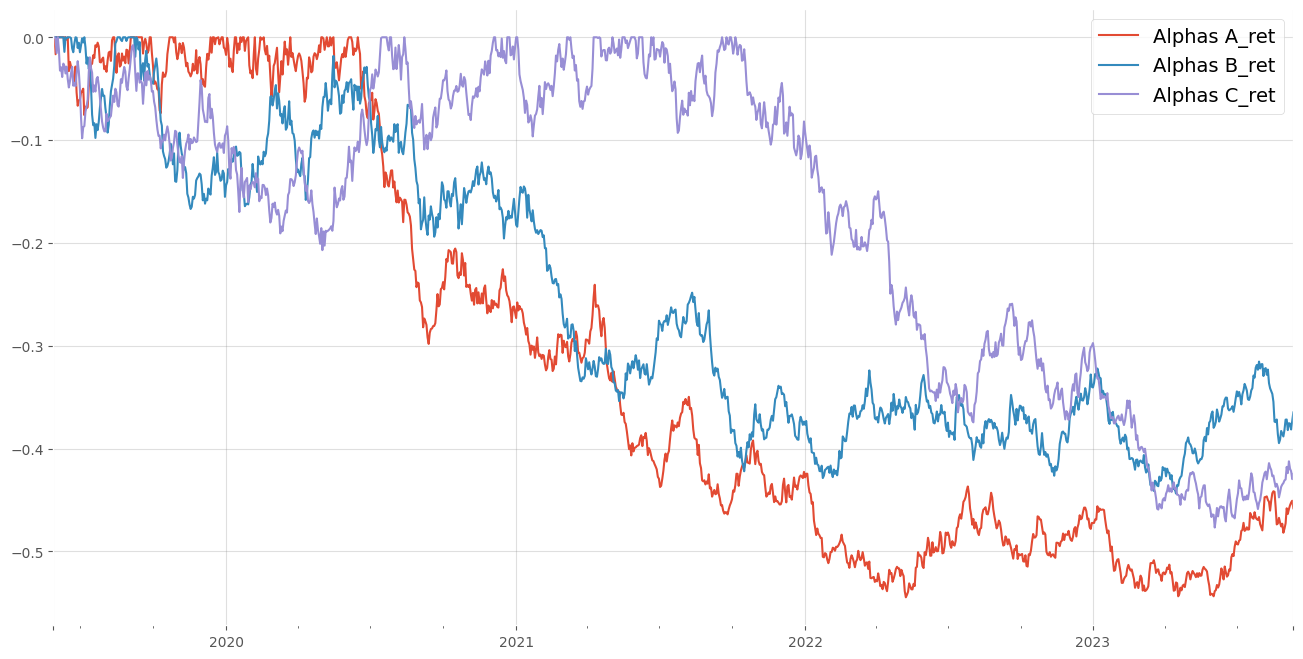

In [17]:
daily_drawdown.plot(figsize=[16,8])

In [18]:
max_drawdown

Alphas A_ret   -0.544602
Alphas B_ret   -0.443717
Alphas C_ret   -0.476758
dtype: float64

In [19]:
for alpha in alphas:
    metrics.loc["MDD", alpha] = max_drawdown[f"{alpha}_ret"]

### <font color = blue> 👉 Question 5</font>. Examining Drawdown Duration:

- Analyze the longest drawdown durations for each strategy.

- Which of the Alphas seems to have the quickest recovery mechanism following a significant drawdown?

### <font color = red> Answer 5 is presented in the cell below: </font>

In [20]:
cummax_return

,Alphas A_ret,Alphas B_ret,Alphas C_ret
2019-05-28,NaN,NaN,NaN
2019-05-29,1.005624,1.019917,1.007340
2019-05-30,1.005624,1.045270,1.007340
2019-05-31,1.010464,1.077991,1.007340
2019-06-03,1.016492,1.077991,1.013235
...,...,...,...
2023-09-06,1.610776,1.363998,1.512298
2023-09-07,1.610776,1.363998,1.512298
2023-09-08,1.610776,1.363998,1.512298
2023-09-11,1.610776,1.363998,1.512298


In [21]:
for i, alpha in enumerate(cummax_return.columns):
    days = cummax_return[alpha].groupby(cummax_return[alpha]).count().sort_values(ascending=False).values[0]
    print(f"{alpha}: Longest Drawdown Duration = {days} days")
    metrics.loc["LDD", alphas[i]] = days

Alphas A_ret: Longest Drawdown Duration = 846 days
Alphas B_ret: Longest Drawdown Duration = 1046 days
Alphas C_ret: Longest Drawdown Duration = 505 days


C is the only strat that has recovered from a drawdown

### <font color = blue> 👉 Question 6</font>. Comprehensive Assessment of Strategy Performance:

- By synthesizing data from metrics such as the Sharpe ratio, cumulative returns trajectory, MDD, and drawdown duration, provide a well-rounded analysis of the three Alphas. 

- Rank and justify your recommendations based on your quantitative insights.

### <font color = red> Answer 6 is presented in the cell below: </font>

In [22]:
metrics

,Alphas A,Alphas B,Alphas C
Sharpe,-0.15583,-0.165371,-0.160252
CAGR,-0.030094,-0.031762,-0.030805
MDD,-0.544602,-0.443717,-0.476758
LDD,846,1046,505


In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
scaler = MinMaxScaler((1,10))
metrics_scaled = pd.DataFrame(
    scaler.fit_transform(metrics.T).T,  # standardize across columns
    index=metrics.index, columns=metrics.columns
)

In [25]:
metrics_scaled

,Alphas A,Alphas B,Alphas C
Sharpe,10.000000,1.0,5.828661
CAGR,10.000000,1.0,6.165290
MDD,1.000000,10.0,7.052348
LDD,6.672828,10.0,1.000000


In [26]:
metrics_scaled.iloc[0:3].sum() - metrics_scaled.iloc[3:4].sum()

Alphas A    14.327172
Alphas B     2.000000
Alphas C    18.046299
dtype: float64

In [27]:
metrics_scaled.iloc[0:3].sum() / metrics_scaled.iloc[3:4].sum()

Alphas A     3.147091
Alphas B     1.200000
Alphas C    19.046299
dtype: float64

In [28]:
metrics_scaled.iloc[0:3].prod() / metrics_scaled.iloc[3:4].prod()

Alphas A     14.986150
Alphas B      1.000000
Alphas C    253.428828
dtype: float64

In [29]:
metrics_scaled.apply(lambda x: (x[0:3].prod() / (x[3])) , axis=0)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_86333/2370924156.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  metrics_scaled.apply(lambda x: (x[0:3].prod() / (x[3])) , axis=0)


Alphas A     14.986150
Alphas B      1.000000
Alphas C    253.428828
dtype: float64

first 3 are positively correlated with good performance and the last one is negative related. Use multiplications since it is growth related metrics

### <font color = blue> 👉 Question 7</font>. Reflecting on the Sharpe Ratio:

- Given the observed disparities in cumulative returns and MDD among the Alphas, even with similar Sharpe ratios, evaluate the effectiveness of relying solely on the Sharpe ratio.

- Can you propose additional or refined metrics to differentiate between Alphas with matching Sharpe values but varying performances in other critical areas?

### <font color = red> Answer 7 is presented in the cell below: </font>

sharpe ratio does not consider drawdowns and the length of draw down.

$$ \frac{1}{2} \left( \text{Sharpe Ratio}  + \text{Max Drawdown}^{Longest Drawdown} \right)$$

## 👇 Questions 8 to 12 ask you to build, execute, and backtest a strategy based on one kind of momentum strategy called the `Moving Average Convergence Divergence` (MACD) crossover.

### <font color = blue> 👉 Question 8</font>. Let’s take a look at Apple (AAPL) as our security of interest, over the three-year period of 2015 through 2017.

#### Moving Average Convergence Divergence (`MACD`) is a lagging, trend-following momentum indicator reflecting the relationship between two moving averages of stock prices.

#### The strategy utilizes two indicators, the MACD and the MACD signal line:

- The MACD is defined as the `difference` between the `12`-day ***exponential*** moving average and the `26`-day exponential moving average.
- The MACD `signal line` is then defined as the `9`-day ***exponential*** moving average of the MACD.

### <font color = green> NOTE: The MACD crossover strategy is defined as:

- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

In [30]:
aapl =\
yf.download("AAPL",
            start = dt.datetime(2015, 1, 1),
            end = dt.datetime(2018, 1, 1),
            auto_adjust = True)['Close']

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

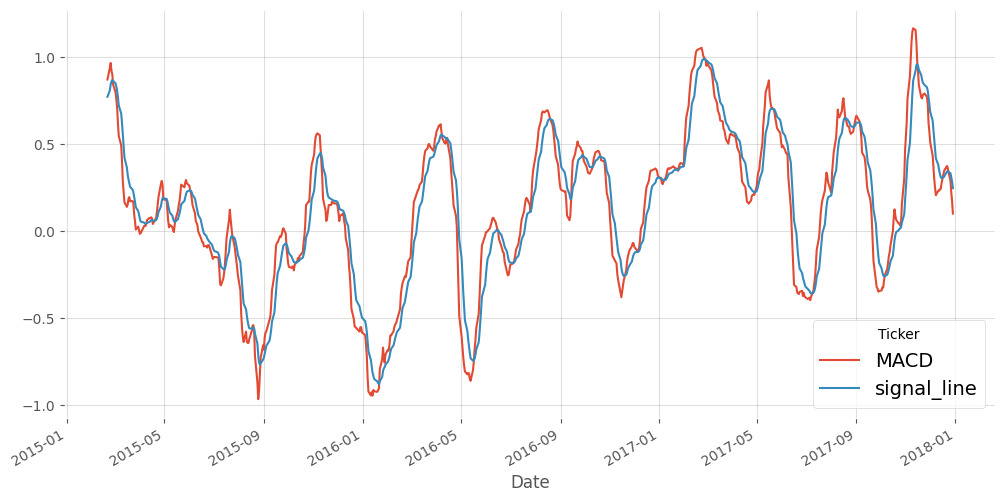

In [31]:

aapl['ema_12'] =\
aapl["AAPL"].ewm(span = 12, 
                 min_periods = 12).mean()
aapl['ema_26'] =\
aapl["AAPL"].ewm(span = 26, 
                 min_periods = 26).mean()
aapl['MACD'] =\
(
    aapl['ema_12'] - aapl['ema_26']
)
aapl['signal_line'] =\
(
    aapl['MACD'].ewm(span = 9,
                       min_periods = 9).mean()
)
aapl = aapl.dropna()


aapl[["MACD", "signal_line"]].plot(figsize = (12, 6))

In [32]:
aapl['signal'] =\
(
    np.where(
        aapl['MACD'] > aapl['signal_line'], 1, -1
    )
)

aapl['trade'] = aapl['signal'].diff()
aapl.loc[aapl.index[0], 'trade'] = 2.0 # first row is buy

### <font color = red> Answer 8 is presented in the cell below: </font>

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_86333/4162764955.py:29: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  .plot(aapl[aapl.trade == 2.0].index,


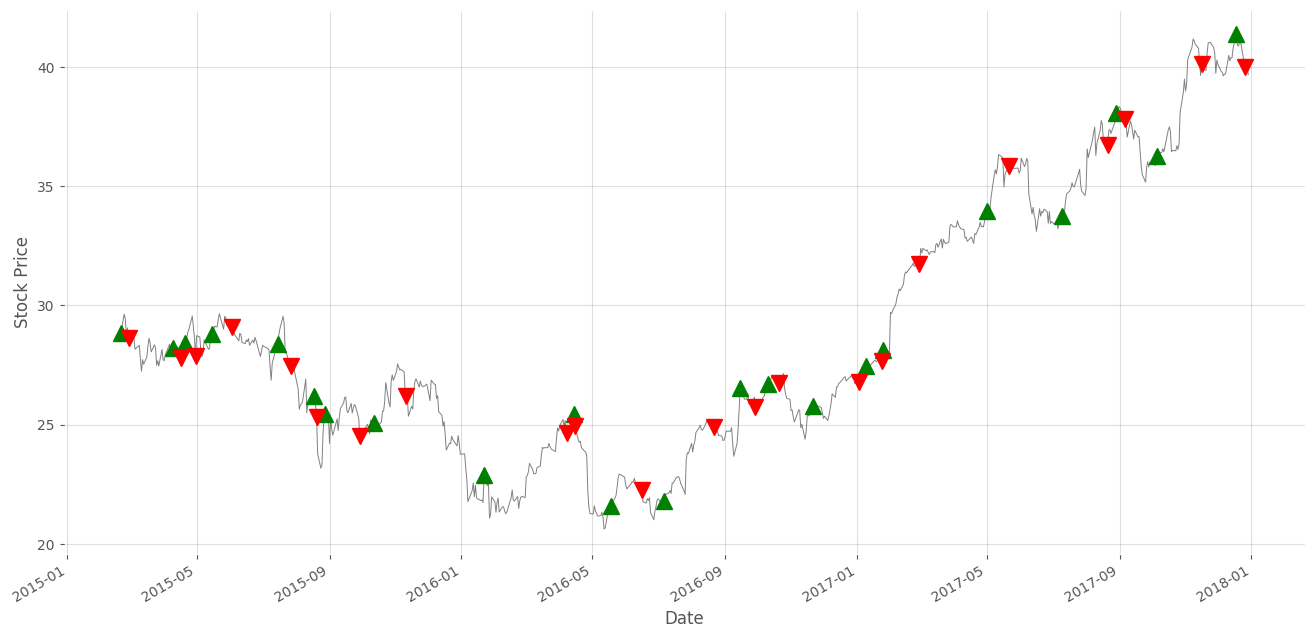

In [33]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    aapl
    ["AAPL"]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# BUY Signal

(
    sub
    .plot(aapl[aapl.trade == 2.0].index,
          aapl.AAPL[aapl.trade == 2.0],
          "^",
          color = "green",
          markersize = 12)
)

# SELL Signal

(
    sub
    .plot(aapl[aapl.trade == -2.0].index,
          aapl.AAPL
          [aapl.trade == -2.0],
          "v",
          color = "red",
          markersize = 12)
)


In [34]:
aapl_melt = aapl.reset_index().rename(columns={'index': 'Date'})

p = (
    ggplot(aapl_melt, aes(x='Date'))
    + geom_line(
        aes(y='AAPL'),
        color='grey',
        size=0.5)
    + geom_point(
        aes(y='AAPL'),
        data=aapl_melt[aapl_melt.trade == 2.0],
        shape=24,
        color='green',
        fill='green',
        size=1)
    + geom_point(
        aes(y='AAPL'),
        data=aapl_melt[aapl_melt.trade == -2.0],
        shape=25,
        color='red',
        fill='red',
        size=1)
    + ggtitle("AAPL Price with Buy/Sell Signals")
    + ylab("Stock Price")
    + xlab("Date")
    + ggsize(1200, 500)
)

p

### <font color = blue> 👉 Question 9</font>. Let’s suppose that you started from a $100,000 capital base for the given security.

### Given a $5 fixed commission fee per trade, how much in cumulative returns could you have had as a result of the MACD crossover strategy?

### Below are the lines of code that lead to an answer:

In [35]:
aapl['passive_return'] =\
(
    np.log(
        aapl['AAPL'] / aapl['AAPL'].shift(1)
    )
)

aapl['strategy_return'] =\
(
    aapl['signal'].shift(1) * aapl['passive_return']
)

In [36]:
aapl = aapl.fillna(0)

In [37]:
aapl.isnull().sum()

Ticker
AAPL               0
ema_12             0
ema_26             0
MACD               0
signal_line        0
signal             0
trade              0
passive_return     0
strategy_return    0
dtype: int64

In [46]:
initial = 100_000
capital = initial

for i, row in aapl.iterrows():
    capital *= np.exp(row['strategy_return'])
    if row['trade'] == 2.0 or row['trade'] == -2.0:  # buy
        capital = capital - 5

print(f"Final capital: ${capital:,.2f}")

Final capital: $184,102.36


In [47]:
cagr =\
(
    (capital / initial) ** (252 / aapl.shape[0]) - 1
)

### <font color = red> Answer 9 </font>

    The answer is ____________ % .

In [49]:
f"The answer is {cagr*100:,.2f}%"

'The answer is 23.74%'

### <font color = blue> 👉 Question 10</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

In [55]:
aapl

Ticker,AAPL,ema_12,ema_26,MACD,signal_line,signal,trade,passive_return,strategy_return
Date,,,,,,,,,
2015-02-20,28.850313,27.804293,26.931792,0.872501,0.773149,1,2.0,0.000000,0.000000
2015-02-23,29.630054,28.085993,27.146162,0.939831,0.810495,1,0.0,0.026668,0.026668
2015-02-24,29.445145,28.295606,27.327834,0.967772,0.844906,1,0.0,-0.006260,-0.006260
2015-02-25,28.692142,28.356738,27.435115,0.921623,0.861382,1,0.0,-0.025906,-0.025906
2015-02-26,29.055279,28.464394,27.561936,0.902458,0.870075,1,0.0,0.012577,0.012577
...,...,...,...,...,...,...,...,...,...
2017-12-22,41.025642,40.689049,40.313681,0.375368,0.345253,1,0.0,0.000000,0.000000
2017-12-26,39.984837,40.580709,40.289322,0.291386,0.334480,-1,-2.0,-0.025697,-0.025697
2017-12-27,39.991863,40.490117,40.267288,0.222829,0.312150,-1,0.0,0.000176,-0.000176


In [61]:
cumrets =\
(
    aapl['strategy_return'].cumsum().apply(np.exp)
)

drawdown =\
(
    cumrets - cumrets.cummax()
)

max_drawdown = drawdown.min()

<Axes: xlabel='Date'>

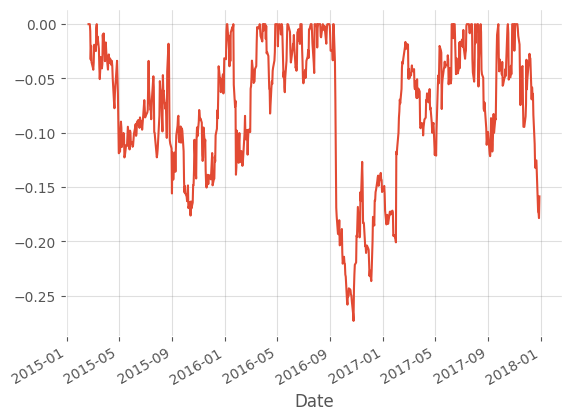

In [65]:
drawdown.plot()

In [69]:
drawdown.sort_values(ascending=True).head(10)

Date
2016-10-25   -0.273103
2016-10-24   -0.266493
2016-10-11   -0.258143
2016-10-10   -0.255318
2016-10-21   -0.254761
2016-10-13   -0.250477
2016-10-20   -0.249575
2016-10-19   -0.248899
2016-10-12   -0.246418
2016-10-18   -0.244953
Name: strategy_return, dtype: float64

In [86]:
# Copy and reset index
dd_reset = drawdown.reset_index()
dd_reset['period'] = (dd_reset['strategy_return'] == 0).cumsum()  # period IDs

# Ignore zero rows (between periods)
dd_nonzero = dd_reset[dd_reset['strategy_return'] != 0]

# Aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date=('Date', 'min'),
    end_date=('Date', 'max'),
    avg_drawdown=('strategy_return', 'mean'),
    max_drawdown=('strategy_return', 'min'),
    duration=('strategy_return', 'size')  # number of trading days
).sort_values(by='avg_drawdown',ascending=True)

period_stats.head(10)


,start_date,end_date,avg_drawdown,max_drawdown,duration
period,,,,,
38,2016-09-12,2017-06-08,-0.129853,-0.273103,187
3,2015-03-12,2016-01-05,-0.091183,-0.176158,207
55,2017-08-16,2017-09-22,-0.080935,-0.121505,27
6,2016-01-22,2016-03-21,-0.080126,-0.138560,41
64,2017-11-09,2017-12-29,-0.076025,-0.178489,35
50,2017-07-27,2017-08-01,-0.041940,-0.052900,4
11,2016-04-05,2016-04-26,-0.040718,-0.082267,16
56,2017-09-26,2017-10-16,-0.040576,-0.056709,15
57,2017-10-18,2017-10-26,-0.039306,-0.051028,7


In [87]:
max_drawdown

np.float64(-0.2731027377686459)

### <font color = red> Answer 10 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

In [89]:
# Assuming period_stats has columns: avg_drawdown, max_drawdown, start_date, end_date
# Sort by worst drawdown
worst_periods = period_stats.head(5).reset_index(drop=True)

for i, row in worst_periods.iterrows():
    rank = i + 1
    net_dd = row['max_drawdown'] * 100  # convert to %
    duration = row['duration']
    if rank == 1:
        label = "The Worst drawdown period"
    else:
        label = f"The {rank}th worst drawdown period"
    
    print(f"{label:<30}: Net drawdown {net_dd:.2f} % | Duration {duration} Trading Days")


The Worst drawdown period     : Net drawdown -27.31 % | Duration 187 Trading Days
The 2th worst drawdown period : Net drawdown -17.62 % | Duration 207 Trading Days
The 3th worst drawdown period : Net drawdown -12.15 % | Duration 27 Trading Days
The 4th worst drawdown period : Net drawdown -13.86 % | Duration 41 Trading Days
The 5th worst drawdown period : Net drawdown -17.85 % | Duration 35 Trading Days


### <font color = blue> 👉 Question 11</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

<Axes: xlabel='Date'>

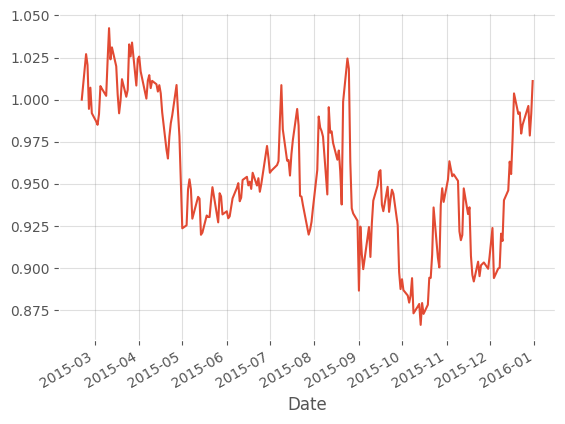

In [104]:
cumrets.loc[:'2015-12-31'].plot()

In [115]:
aapl_15 = cumrets.loc[:'2015-12-31']
aapl_16 = cumrets.loc['2015-12-31':'2016-12-31']
aapl_17 = cumrets.loc['2016-12-31':'2017-12-31']


aapl_15_cagr = ((aapl_15.iloc[-1] / aapl_15.iloc[0]) ** (252 / aapl_15.shape[0]) -1)
aapl_16_cagr = ((aapl_16.iloc[-1] / aapl_16.iloc[0]) ** (252 / aapl_16.shape[0]) -1)
aapl_17_cagr = ((aapl_17.iloc[-1] / aapl_17.iloc[0]) ** (252 / aapl_17.shape[0]) -1)

ave_cagr = (aapl_15_cagr + aapl_16_cagr + aapl_17_cagr)/3 * 100

In [118]:
print(f"Average CAGR over 2015, 2016, 2017: {ave_cagr:.2f}%")
print(f"2015: {aapl_15_cagr*100:.2f}%, \n2016: {aapl_16_cagr*100:.2f}%, \n2017: {aapl_17_cagr*100:.2f}%")

Average CAGR over 2015, 2016, 2017: 23.72%
2015: 1.27%, 
2016: 39.74%, 
2017: 30.14%


### <font color = red> Answer 11 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

In [122]:
print(f"Below average year(s): {[year for year, cagr in zip([2015, 2016, 2017], 
                                                      [aapl_15_cagr, aapl_16_cagr, aapl_17_cagr]) if cagr*100 < ave_cagr]}")
print(f"Above average year(s): {[year for year, cagr in zip([2015, 2016, 2017], 
                                                      [aapl_15_cagr, aapl_16_cagr, aapl_17_cagr]) if cagr*100 > ave_cagr]}")

Below average year(s): [2015]
Above average year(s): [2016, 2017]


###  <font color = blue> 👉 Question 12. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

In [126]:
sharpe = aapl.strategy_return.mean() / aapl.strategy_return.std() * np.sqrt(252)

### <font color = red> Answer 12 </font>
    
    Sharpe ratio: __________
    

In [130]:
f"Sharpe ratio: {sharpe:1f}"

'Sharpe ratio: 0.953032'

### <font color="green">"💯 Thank you for putting your efforts into the exercise problem sets 😊"</font>